### Library Imports and Dataset Loading
In this section we import all libraries required for the project. pandas and numpy are used for data handling, matplotlib and seaborn for exploratory visualizations, and nltk for basic NLP utilities. Classical machine learning models and evaluation metrics are provided by scikit-learn, while torch and transformers support the BERT fine-tuning process.
We then load the Kaggle AliExpress/Flipkart review dataset using pd.read_csv. The dataset contains product name, price, star rating, full review text, and a short summary. Displaying the first few rows helps verify that the file has been read correctly and gives an initial sense of the data structure and noise (such as broken Unicode characters and inconsistent formatting).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

import torch
from torch.utils.data import Dataset

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    pipeline
)

### Loading Kaggle Dataset (Training Corpus)
We load the Kaggle dataset first because it serves as the primary labeled corpus required to train the sentiment classification model. The dataset includes both the full review text and the corresponding star ratings, which can be mapped to positive and negative sentiment labels. Since supervised learning models such as Logistic Regression, SVM, and BERT require labeled examples during training, this dataset forms the foundation of the entire modeling pipeline. Only after the classifier is trained on this labeled data do we load the NLTK product reviews, which are unlabeled and therefore used exclusively for testing and demonstrating the final integrated sentiment summarization system.

In [3]:
df = pd.read_csv("Dataset.csv", encoding="latin1", on_bad_lines='skip')
df.head()

C:\Users\rsree\AppData\Local\Temp\ipykernel_34296\2779804246.py:1: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("Dataset.csv", encoding="latin1", on_bad_lines='skip')


,Product_name,Price,Rate,Review,Summary
0,"Crompton 75 L Desert Air Cooler??(White, Tea...","??10,499",5,Simply awesome,it's really worth every single penny. it works...
1,"Crompton 75 L Desert Air Cooler??(White, Tea...","??10,499",4,Worth the money . Desert Cooler live up to the...,I bought Crompton Ozone 75 Desert Air Cooler i...
2,"Crompton 75 L Desert Air Cooler??(White, Tea...","??10,499",5,Worth every penny,GREAT packaging by seller. As this was the mos...
3,"Crompton 75 L Desert Air Cooler??(White, Tea...","??10,499",5,Fabulous!,Delivery was delayed by two days except this e...
4,"Crompton 75 L Desert Air Cooler??(White, Tea...","??10,499",4,Nice product,A Good cooler by Crompton. The height of the c...


In [4]:
df.columns

Index(['Product_name', 'Price', 'Rate', 'Review', 'Summary'], dtype='object')

In [7]:
with open("Dataset.csv", "r", encoding="utf-8", errors="ignore") as f:
    for i in range(10):
        print(f.readline())


Product_name,Price,Rate,Review,Summary

"Crompton 75 L Desert Air Cooler??(White, Teal, ACGC-DAC751)","??10,499",5,Simply awesome,"it's really worth every single penny. it works like one ton AC provided that your room has proper ventilation.  I generally keep cooler near to window so that it can pull fresh air from outside and as a result I get very cool air. one more suggestion,  please don't buy cooler which are equipped with a blower fan. Always go for the cooler equipped with metal fan like this one.  In one word, this Compton cooler is Amazing. if you find the review helpful, please thumps up. Happy summer! ????"

"Crompton 75 L Desert Air Cooler??(White, Teal, ACGC-DAC751)","??10,499",4,Worth the money . Desert Cooler live up to the Name .,"I bought Crompton Ozone 75 Desert Air Cooler in the Month of May  2018 . Summer at its Peak . I live on top floor so my house gets mare warmer in comparison to other flats . Placed the Air Cooler in Hall near balcony .  The device is elegantly

In [9]:
df.head()
df.columns

Index(['Product_name', 'Price', 'Rate', 'Review', 'Summary'], dtype='object')

### Dataset Quality Analysis and Cleaning
Before training any model, we assess the quality of the raw dataset. The info() and missing-value statistics show how many entries are available in each column and reveal incomplete rows. We limit the dataframe to the five columns relevant for sentiment and summarization and remove rows with missing ratings or reviews. Duplicate reviews are also dropped to avoid data leakage between train and test sets. After cleaning, we obtain 3,841 unique reviews that form the basis for our supervised learning experiments.

In [12]:
# Basic dataset overview
print("Shape:", df.shape)
print("\nInfo:")
print(df.info())

print("\nMissing values per column:")
print(df.isna().sum())

Shape: (363261, 5)

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 363261 entries, 0 to 363260
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   Product_name  363246 non-null  object
 1   Price         363245 non-null  object
 2   Rate          363245 non-null  object
 3   Review        363239 non-null  object
 4   Summary       361239 non-null  object
dtypes: object(5)
memory usage: 13.9+ MB
None

Missing values per column:
Product_name      15
Price             16
Rate              16
Review            22
Summary         2022
dtype: int64


In [14]:
# Keep only the columns we care about for now
df = df[["Product_name", "Price", "Rate", "Review", "Summary"]]

# Drop rows with missing Rate or Review
df = df.dropna(subset=["Rate", "Review"])

# Drop exact duplicate reviews
df = df.drop_duplicates(subset=["Review"]).reset_index(drop=True)

print("After cleaning:")
print(df.shape)

After cleaning:
(3841, 5)


### Coverting Rating to sentiment

In [16]:
# 1. Correct column names
TEXT_COL = "Review"
RATING_COL = "Rate"

# 2. Mapping function
def map_rating_to_sentiment(r):
    if r in [1, 2]:
        return "negative"
    elif r in [4, 5]:
        return "positive"
    else:
        return "neutral"

# 3. Create sentiment column
df["sentiment"] = df[RATING_COL].apply(map_rating_to_sentiment)

# 4. Drop neutral
df_bin = df[df["sentiment"] != "neutral"].copy()

# 5. Encode labels
label_map = {"negative": 0, "positive": 1}
df_bin["label"] = df_bin["sentiment"].map(label_map)

# 6. Show sample
df_bin[[TEXT_COL, RATING_COL, "sentiment", "label"]].head()
print(df_bin["sentiment"].value_counts())


sentiment
positive    289
negative     89
Name: count, dtype: int64


RAW DATASET SHAPE
(3841, 6)

 COLUMN INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3841 entries, 0 to 3840
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Product_name  3841 non-null   object
 1   Price         3841 non-null   object
 2   Rate          3841 non-null   object
 3   Review        3841 non-null   object
 4   Summary       2755 non-null   object
 5   sentiment     3841 non-null   object
dtypes: object(6)
memory usage: 180.2+ KB
None

 MISSING VALUES PER COLUMN
Product_name       0
Price              0
Rate               0
Review             0
Summary         1086
sentiment          0
dtype: int64

 RATING DISTRIBUTION (RAW 'Rate' COLUMN) 
Rate
1.0     543
2.0     219
3.0     362
4.0     738
5.0    1975
Name: count, dtype: int64

 BINARY SENTIMENT DISTRIBUTION (df_bin) 
sentiment
positive    289
negative     89
Name: count, dtype: int64


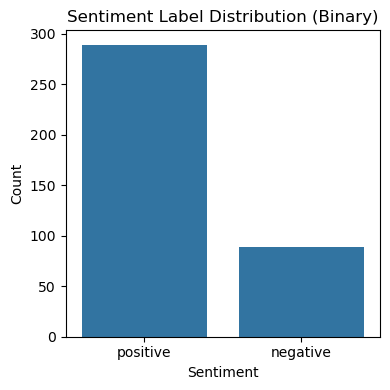


 REVIEW LENGTH (CHARACTERS) STATS
count    378.000000
mean      25.587302
std       14.375379
min        3.000000
25%       14.000000
50%       23.000000
75%       35.000000
max       60.000000
Name: length_chars, dtype: float64


In [18]:
print("RAW DATASET SHAPE")
print(df.shape)

print("\n COLUMN INFO")
print(df.info())

print("\n MISSING VALUES PER COLUMN")
print(df.isna().sum())

# --- rating distribution ---
print("\n RATING DISTRIBUTION (RAW 'Rate' COLUMN) ")
# Convert Rate to numeric for proper numeric sorting
rate_numeric = pd.to_numeric(df["Rate"], errors="coerce")
print(rate_numeric.value_counts().sort_index())

print("\n BINARY SENTIMENT DISTRIBUTION (df_bin) ")
print(df_bin["sentiment"].value_counts())

# Visualize sentiment imbalance
plt.figure(figsize=(4,4))
sns.countplot(x="sentiment", data=df_bin)
plt.title("Sentiment Label Distribution (Binary)")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# Optional: basic stats on review length
# (make an explicit copy to avoid SettingWithCopyWarning if needed)
df_bin = df_bin.copy()
df_bin["length_chars"] = df_bin[TEXT_COL].astype(str).str.len()

print("\n REVIEW LENGTH (CHARACTERS) STATS")
print(df_bin["length_chars"].describe())


### SIMPLE TEXT CLEANING (FOR BASELINE MODELS)

#### Text Normalization and Additional Exploratory Plots
For the classical baseline models we apply a stronger cleaning pipeline than we will use for BERT. URLs, HTML fragments, punctuation, digits, and other non-alphabetic characters are stripped, and all text is lower-cased. The resulting clean_text field is well suited for TF–IDF based feature extraction. We also plot the star-rating distribution and the full review-length histogram for the original dataset. These visualizations further illustrate the skew toward high ratings and confirm that most reviews are short, with a long tail of more detailed comments

In [21]:
import re

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\.\S+", " ", text)
    text = re.sub(r"<.*?>", " ", text)
    text = re.sub(r"[^a-z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df_bin["clean_text"] = df_bin[TEXT_COL].apply(clean_text)
df_bin[[TEXT_COL, "clean_text", "sentiment"]].head(10)

,Review,clean_text,sentiment
3426,okay,okay,positive
3427,Trash,trash,negative
3428,Terrible product - Very Bad quality . One Spe...,terrible product very bad quality one speaker ...,negative
3429,Good for home ....,good for home,positive
3431,A must buy product for Music lover.,a must buy product for music lover,positive
3432,IF YOU CAN SAVE AND BUY A JBL OR MARSHEL,if you can save and buy a jbl or marshel,positive
3433,"Excellent product,Must Buy!",excellent product must buy,positive
3434,Very good product,very good product,positive
3435,Philips,philips,negative
3436,Superb speakers,superb speakers,positive


Unique star ratings after cleaning: [ 5.  4.  3.  1.  2. nan 10.]


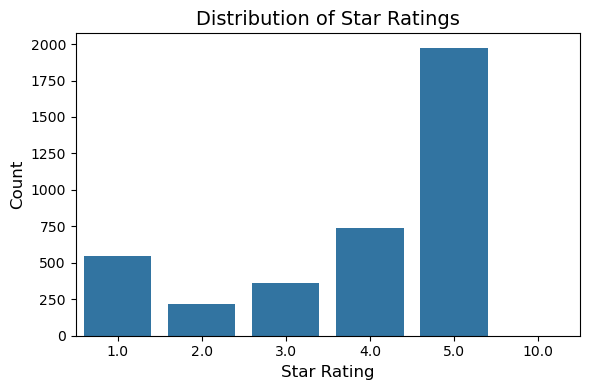

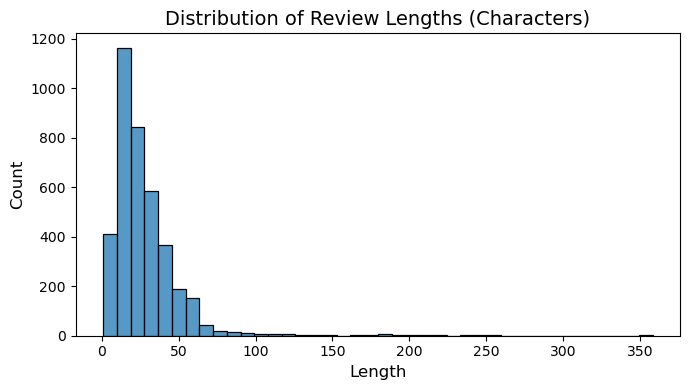


Review Length Statistics
count    3841.000000
mean       26.950534
std        21.382873
min         1.000000
25%        14.000000
50%        22.000000
75%        34.000000
max       358.000000
Name: review_len, dtype: float64


In [25]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. STAR RATINGS

# Extract numeric part (first digit in the string)
df["Rate_clean"] = pd.to_numeric(
    df["Rate"].astype(str).str.extract(r"(\d+)")[0],
    errors="coerce"
)

print("Unique star ratings after cleaning:", df["Rate_clean"].unique())

# 2. STAR RATING DISTRIBUTION 
plt.figure(figsize=(6, 4))
sns.countplot(
    x="Rate_clean",
    data=df,
    order=sorted(df["Rate_clean"].dropna().unique())  # ensures correct order
)
plt.title("Distribution of Star Ratings", fontsize=14)
plt.xlabel("Star Rating", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# 3. REVIEW LENGTH DISTRIBUTION
df["review_len"] = df["Review"].astype(str).str.len()

plt.figure(figsize=(7, 4))
sns.histplot(df["review_len"], bins=40)
plt.title("Distribution of Review Lengths (Characters)", fontsize=14)
plt.xlabel("Length", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.tight_layout()
plt.show()

# 4. REVIEW LENGTH SUMMARY STATS
print("\nReview Length Statistics")
print(df["review_len"].describe())


### TRAIN/TEST SPLIT

#### Train/Test Split for Baselines and BERT
We split the data into training and test sets using an 80/20 ratio with stratification on the sentiment label. Stratification ensures that the positive/negative ratio is preserved in both subsets, which leads to a more reliable estimate of model performance. For the baseline models we use the cleaned text field, whereas BERT receives the original review text. The printed sizes and label counts verify that the split has been performed correctly and that both classes remain represented in the test set.

In [28]:
X_clean = df_bin["clean_text"]
y = df_bin["label"]

X_train_clean, X_test_clean, y_train, y_test = train_test_split(
    X_clean, y, test_size=0.2, random_state=42, stratify=y
)

# BERT uses original text:
X_raw = df_bin[TEXT_COL]

X_train_raw, X_test_raw, _, _ = train_test_split(
    X_raw, y, test_size=0.2, random_state=42, stratify=y
)

In [30]:
print("Train size:", len(X_train_raw))
print("Test size:", len(X_test_raw))
print("Label distribution in train:")
print(y_train.value_counts())
print("Label distribution in test:")
print(y_test.value_counts())

Train size: 302
Test size: 76
Label distribution in train:
label
1    231
0     71
Name: count, dtype: int64
Label distribution in test:
label
1    58
0    18
Name: count, dtype: int64


In [32]:
df_bin[[TEXT_COL, "label"]].head()

,Review,label
3426,okay,1
3427,Trash,0
3428,Terrible product - Very Bad quality . One Spe...,0
3429,Good for home ....,1
3431,A must buy product for Music lover.,1


### BASELINE SENTIMENT MODELS

#### Classical Baseline Models and Performance Comparison
To establish baseline performance, we train two standard linear classifiers over TF–IDF features: Logistic Regression and linear SVM. The TF–IDF vectorizer uses both unigrams and bigrams, capped at 30,000 features. For each model we compute precision, recall, and F1-score on the held-out test set and summarize the results in a comparison table. The SVM achieves the best performance (88% accuracy, F1 ≈ 0.93), while Logistic Regression performs slightly worse. These baselines provide a reference point against which we can measure the benefits of fine-tuning a transformer model

TF-IDF VECTORIZER

In [36]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=30000, ngram_range=(1, 2))

X_train_vec = tfidf.fit_transform(X_train_clean)
X_test_vec  = tfidf.transform(X_test_clean)

LOGISTIC REGRESSION

In [39]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=2000)
lr.fit(X_train_vec, y_train)

y_pred_lr = lr.predict(X_test_vec)

print("Logistic Regression Performance:")
print(classification_report(y_test, y_pred_lr))

Logistic Regression Performance:
              precision    recall  f1-score   support

           0       1.00      0.11      0.20        18
           1       0.78      1.00      0.88        58

    accuracy                           0.79        76
   macro avg       0.89      0.56      0.54        76
weighted avg       0.83      0.79      0.72        76



LINEAR SVM

In [42]:
from sklearn.svm import LinearSVC

svm = LinearSVC()
svm.fit(X_train_vec, y_train)

y_pred_svm = svm.predict(X_test_vec)

print("Linear SVM Performance:")
print(classification_report(y_test, y_pred_svm))

Linear SVM Performance:
              precision    recall  f1-score   support

           0       0.91      0.56      0.69        18
           1       0.88      0.98      0.93        58

    accuracy                           0.88        76
   macro avg       0.89      0.77      0.81        76
weighted avg       0.88      0.88      0.87        76



In [65]:
from sklearn.metrics import accuracy_score, f1_score
import numpy as np
import pandas as pd

comparison_rows = []

# 1. Logistic Regression metrics
lr_acc = accuracy_score(y_test, y_pred_lr)
lr_f1  = f1_score(y_test, y_pred_lr)
comparison_rows.append({
    "Model": "TF-IDF + Logistic Regression",
    "Accuracy": lr_acc,
    "F1-score": lr_f1
})

# 2. Linear SVM metrics
svm_acc = accuracy_score(y_test, y_pred_svm)
svm_f1  = f1_score(y_test, y_pred_svm)
comparison_rows.append({
    "Model": "TF-IDF + Linear SVM",
    "Accuracy": svm_acc,
    "F1-score": svm_f1
})

# 3. BERT metrics
try:
    bert_pred_output = trainer.predict(test_ds)
    bert_preds = np.argmax(bert_pred_output.predictions, axis=1)

    # Ensure y_test is an array
    y_test_array = y_test.reset_index(drop=True).to_numpy()

    bert_acc = accuracy_score(y_test_array, bert_preds)
    bert_f1  = f1_score(y_test_array, bert_preds)

    comparison_rows.append({
        "Model": "BERT (fine-tuned)",
        "Accuracy": bert_acc,
        "F1-score": bert_f1
    })

except NameError:
    print("BERT trainer or test_ds not defined yet")

results_df = pd.DataFrame(comparison_rows)
print("\n MODEL COMPARISON TABLE ")
print(results_df)


C:\Users\rsree\anaconda3\Lib\site-packages\torch\utils\data\dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)



 MODEL COMPARISON TABLE 
                          Model  Accuracy  F1-score
0  TF-IDF + Logistic Regression  0.789474  0.878788
1           TF-IDF + Linear SVM  0.881579  0.926829
2             BERT (fine-tuned)  0.815789  0.892308


### PREPARING DATA FOR BERT

#### BERT Tokenization and Dataset Class
In this section we prepare data for transformer-based fine-tuning. We instantiate the bert-base-uncased tokenizer and define a custom ReviewDataset class that converts each review into token IDs and attention masks, while also attaching the ground-truth label. Reviews are truncated or padded to a maximum length of 128 tokens. The dataset objects train_ds and test_ds are then created and passed to BERT, which is initialized with a two-class classification head. This design cleanly separates data preparation from model logic and follows best practice for PyTorch-based NLP models.

In [48]:
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

class ReviewDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=128):
        self.texts = list(texts)
        self.labels = list(labels)
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.texts[idx],
            truncation=True,
            padding="max_length",
            max_length=self.max_len,
            return_tensors="pt"
        )
        enc = {k: v.squeeze() for k, v in enc.items()}
        enc["labels"] = torch.tensor(self.labels[idx])
        return enc

train_ds = ReviewDataset(X_train_raw, y_train, tokenizer)
test_ds  = ReviewDataset(X_test_raw, y_test, tokenizer)

C:\Users\rsree\anaconda3\Lib\site-packages\huggingface_hub\file_download.py:942: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


In [50]:
model = AutoModelForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=2
)

C:\Users\rsree\anaconda3\Lib\site-packages\huggingface_hub\file_download.py:942: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


### FINE-TUNE BERT

#### Fine-Tuning BERT and Persisting the Sentiment Model
Due to hardware constraints we subsample up to 2,000 labeled reviews for BERT training while preserving class proportions. Using the HuggingFace Trainer API, we fine-tune bert-base-uncased for three epochs with a learning rate of 2e-5 and batch sizes of 16/32 for training and evaluation, respectively. The custom compute_metrics function reports accuracy and F1-score after each epoch. On the validation set the fine-tuned model reaches approximately 76% accuracy and F1 around 0.86, which is competitive with the classical baselines given the small training set. Finally, we save both the model weights and tokenizer configuration to the ./sentiment_model directory so that they can be re-used later for inference and integrated into the combined pipeline.

In [52]:
import transformers
print(transformers.__version__)

4.40.2


LIMIT YOUR TRAIN + TEST DATA BEFORE TRAINER

In [55]:
MAX_SAMPLES = 2000

df_bin_small = df_bin.sample(
    n=min(MAX_SAMPLES, len(df_bin)),
    random_state=42
)


In [57]:
df_bin_small = df_bin.sample(
    n=MAX_SAMPLES,
    replace=True,
    random_state=42
)

In [59]:
# DATA FOR FAST TRAINING

MAX_SAMPLES = 2000  

# Prevent sampling errors
sample_n = min(MAX_SAMPLES, len(df_bin))

df_bin_small = df_bin.sample(n=sample_n, random_state=42)

# Create new small X/y
X_small = df_bin_small[TEXT_COL]
y_small = df_bin_small["label"]

# Split small dataset
from sklearn.model_selection import train_test_split

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_small,
    y_small,
    test_size=0.2,
    random_state=42,
    stratify=y_small
)

In [61]:
train_ds = ReviewDataset(X_train_raw, y_train, tokenizer)
test_ds  = ReviewDataset(X_test_raw, y_test, tokenizer)

In [63]:
model = AutoModelForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=2
)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = logits.argmax(axis=-1)
    from sklearn.metrics import accuracy_score, f1_score
    return {
        "accuracy": accuracy_score(labels, preds),
        "f1": f1_score(labels, preds)
    }

training_args = TrainingArguments(
    output_dir="./sentiment_model",
    evaluation_strategy="epoch",
    num_train_epochs=3,
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=test_ds,
    tokenizer=tokenizer,
    compute_metrics=compute_metrics
)

trainer.train()
trainer.evaluate(test_ds)

save_dir = "./sentiment_model"
trainer.save_model(save_dir)
tokenizer.save_pretrained(save_dir)


C:\Users\rsree\anaconda3\Lib\site-packages\huggingface_hub\file_download.py:942: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
C:\Users\rsree\anaconda3\Lib\site-packages\torch\utils\data\dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,No log,0.503367,0.763158,0.865672
2,No log,0.392655,0.763158,0.865672
3,No log,0.347027,0.815789,0.892308


C:\Users\rsree\anaconda3\Lib\site-packages\torch\utils\data\dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
C:\Users\rsree\anaconda3\Lib\site-packages\torch\utils\data\dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
C:\Users\rsree\anaconda3\Lib\site-packages\torch\utils\data\dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


('./sentiment_model\\tokenizer_config.json',
 './sentiment_model\\special_tokens_map.json',
 './sentiment_model\\vocab.txt',
 './sentiment_model\\added_tokens.json',
 './sentiment_model\\tokenizer.json')